<a href="https://colab.research.google.com/github/corrielynnyuill-debug/AIProject_Images-CLY/blob/main/AIProject_Part4_CorrieLynnYuill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(60000, 784)
--------------------------------------------------------------------------------
(60000,)
--------------------------------------------------------------------------------
[0 1 2 3 4 5 6 7 8 9]
--------------------------------------------------------------------------------
Flattened shape: (60000, 784)
--------------------------------------------------------------------------------


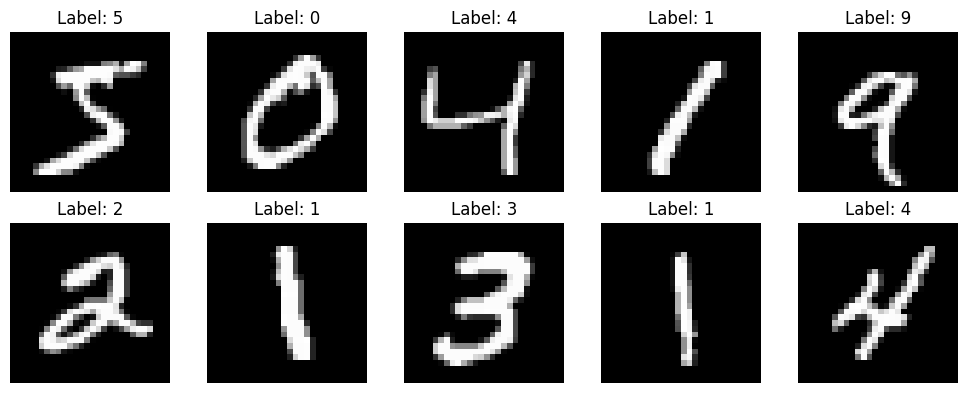

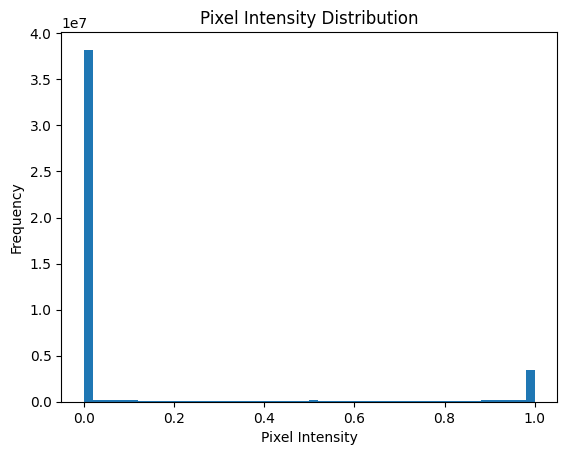

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten + normalize
X = X_train.reshape(-1, 28*28) / 255.0
y = y_train

# Basic EDA
print( X.shape)
print('-'*80)
print(y.shape)
print('-'*80)
print(np.unique(y))
print('-'*80)

# Flatten
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)

# Normalize to [0,1]
X_train_norm = X_train_flat / 255.0
X_test_norm = X_test_flat / 255.0

print("Flattened shape:", X_train_norm.shape)
print('-'*80)

# Visualize sample images
fig, axes = plt.subplots(2,5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28,28), cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Explore Pixel Intensity Distribution
plt.hist(X_train_norm.flatten(), bins=50)
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Pixel Intensity Distribution')
plt.show()


Running KMeans for k=5
Running KMeans for k=6
Running KMeans for k=7
Running KMeans for k=8
Running KMeans for k=9
Running KMeans for k=10
Running KMeans for k=11
Running KMeans for k=12
Running KMeans for k=13
Running KMeans for k=14
Running KMeans for k=15


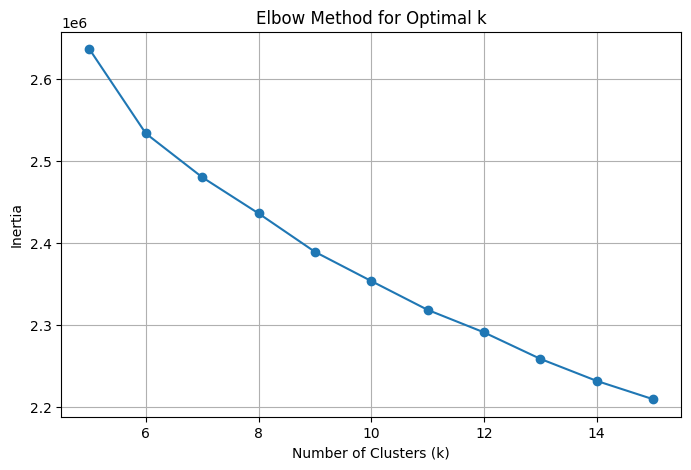

Cluster labels shape (60000,)


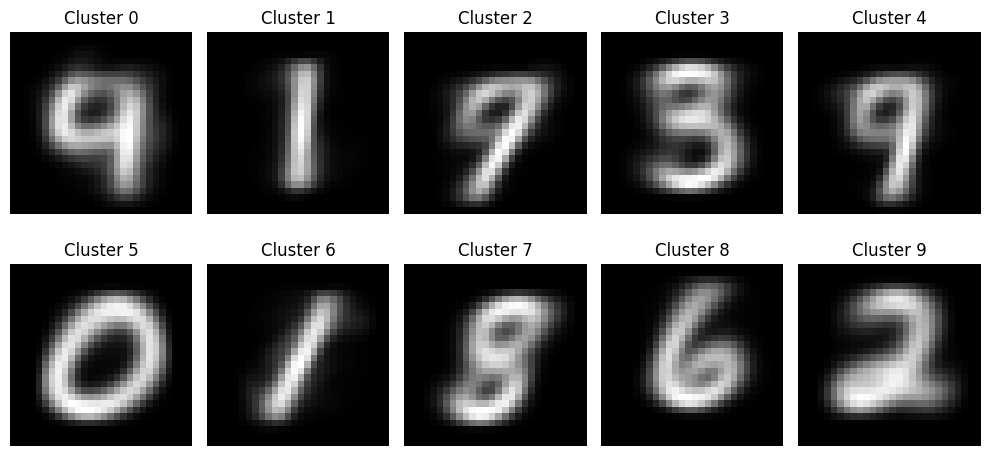

Cluster 0: 5416 samples
Cluster 1: 5498 samples
Cluster 2: 6691 samples
Cluster 3: 7790 samples
Cluster 4: 7239 samples
Cluster 5: 4975 samples
Cluster 6: 5297 samples
Cluster 7: 7063 samples
Cluster 8: 5395 samples
Cluster 9: 4636 samples


In [6]:
from sklearn.cluster import KMeans

# Elbow method to find optimal clusters
inertias = []
k_values = range(5,16) # test k = 5 to 15

for k in k_values:
    print(f'Running KMeans for k={k}')
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_norm)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# Fit KMeans with k=10
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(X_train_norm)

cluster_labels = kmeans.labels_
print('Cluster labels shape', cluster_labels.shape)

# Visualize Cluster Centroids
fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    centroid = kmeans.cluster_centers_[i].reshape(28,28)
    ax.imshow(centroid, cmap='gray')
    ax.set_title(f'Cluster {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Cluster size distribution
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'Cluster {u}: {c} samples')


Predicted cluster labels shape (10000,)


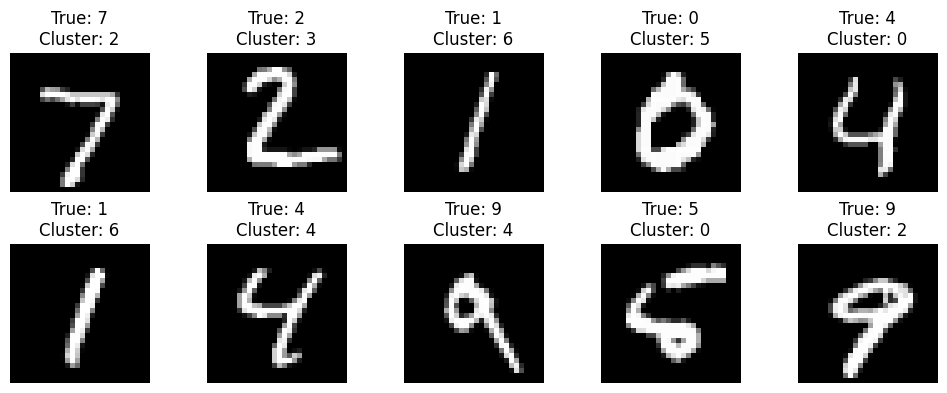

true_label    0    1    2    3    4    5    6    7    8    9
cluster                                                     
0            14    0   34    7  366   28  125   76   18  225
1             0  660   50   58   18   20   24   36   33   16
2             2    0   11    8  249   57    0  425   34  241
3            57    3   76  685    0  297    1    0  250    7
4             2    0    9   18  297   50    2  429   44  489
5           781    0   13    4    0    6   16    1    7    7
6             5  469   86    5   24   91   19   48   47    7
7            74    1   24  178    2  316   26    1  525   13
8            41    2   20    9   23   23  737    1   10    2
9             4    0  709   38    3    4    8   11    6    2
cluster
0    4
1    1
2    7
3    3
4    9
5    0
6    1
7    8
8    6
9    2
dtype: uint8
Cluster-based pseudo-accuracy: 0.5846


In [7]:
# Predict Cluster Assignments for new images
test_clusters = kmeans.predict(X_test_norm)
print('Predicted cluster labels shape', test_clusters.shape)

# Visualize Predictions on sample test images
fig, axes = plt.subplots(2,5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    ax.set_title(f'True: {y_test[i]}\nCluster: {test_clusters[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Build Cluster-Digit Cross-Tab (Confusion Matrix Style)
df = pd.DataFrame({
    'true_label': y_test,
    'cluster': test_clusters})

cross_tab = pd.crosstab(df['cluster'], df['true_label'])
print(cross_tab)

# Cluster to Digit Mapping
cluster_to_digit = cross_tab.idxmax(axis=1)
print(cluster_to_digit)

# evaluate how well clusters match digits
mapped_predictions = cluster_to_digit[test_clusters].astype(int)
accuracy = np.mean(mapped_predictions == y_test).mean()
print(f'Cluster-based pseudo-accuracy: {accuracy}')


PCA shape: (60000, 2)


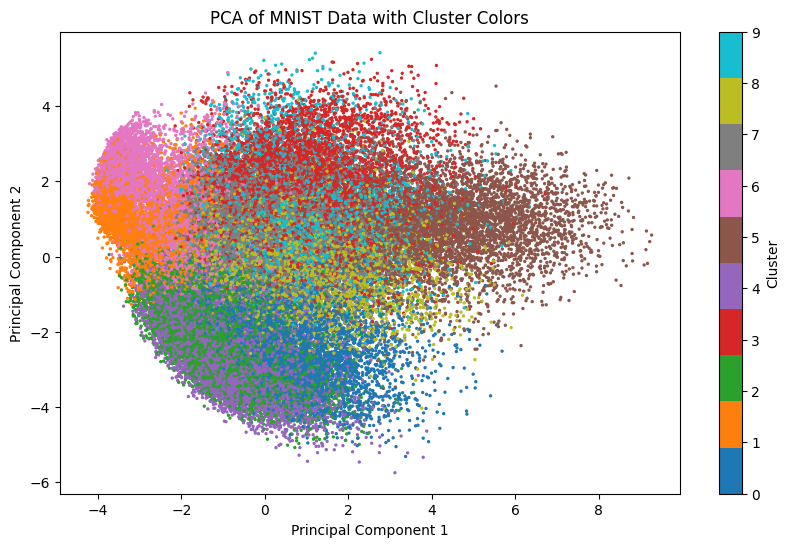

t-SNE shape: (10000, 2)


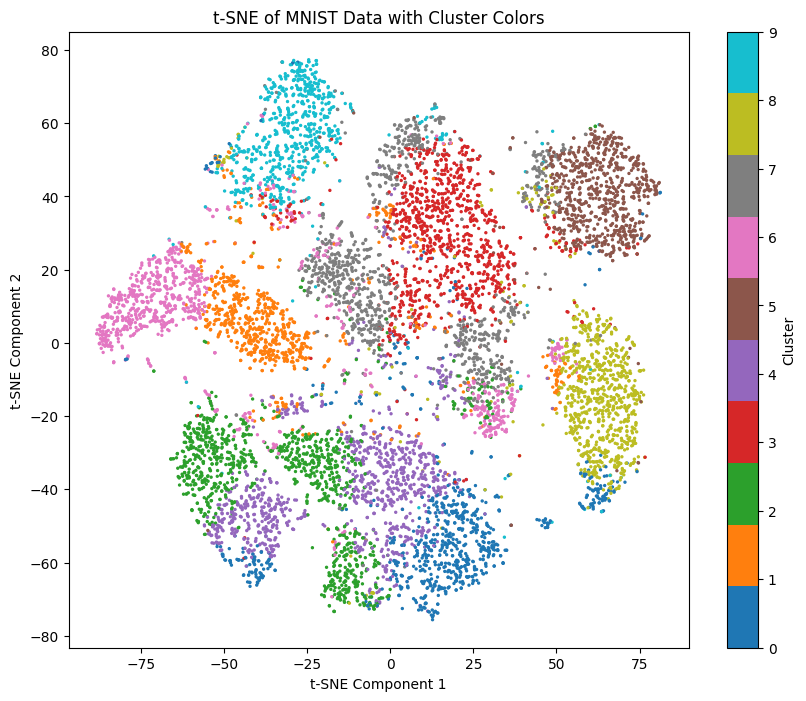

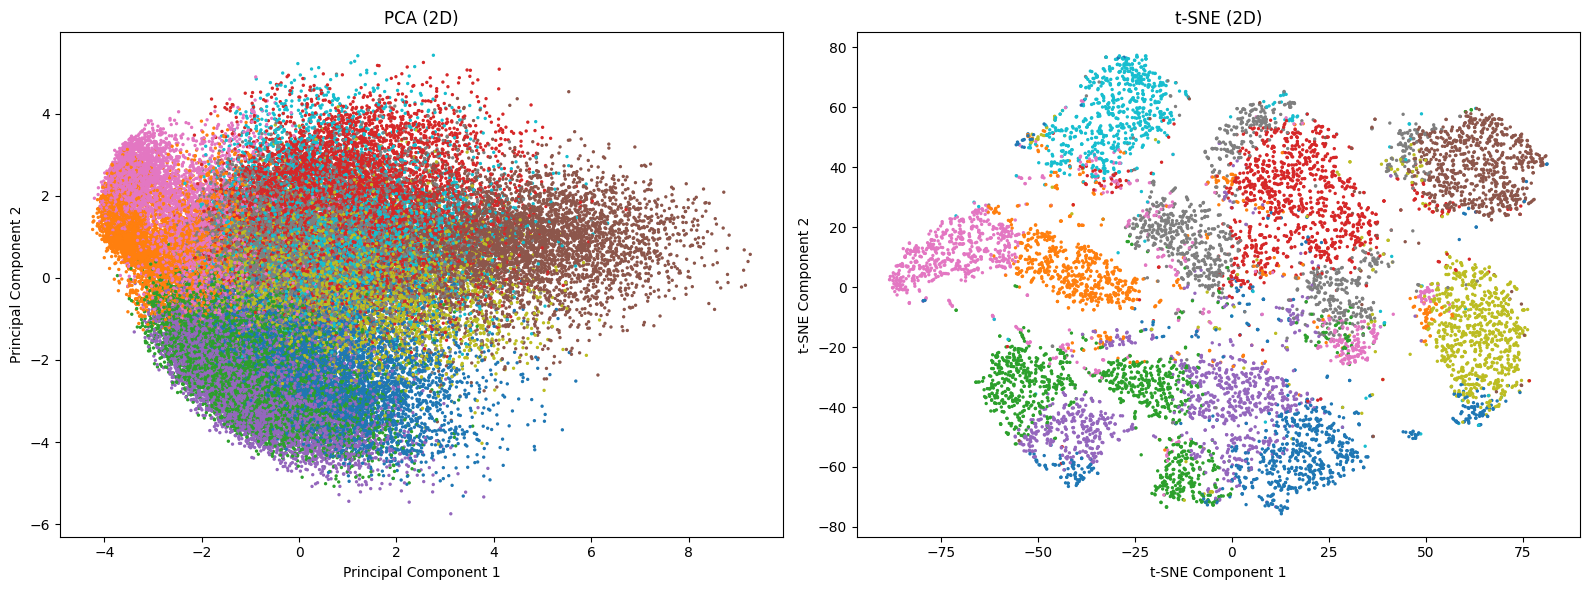

In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA to 2 Dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_norm)

print('PCA shape:' , X_pca.shape)

# Plot PCA with Cluster Colors
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      c=cluster_labels, cmap='tab10', s=2)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Data with Cluster Colors')
plt.colorbar(scatter, label='Cluster')
plt.show()

# t-SNE to 2 Dimensions
# Subsample for speed
n_samples = 10000
X_subset = X_train_norm[:n_samples]
labels_subset = cluster_labels[:n_samples]

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_subset)

print('t-SNE shape:' , X_tsne.shape)

# Plot t-SNE with Cluster colors
plt.figure(figsize=(10,8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1],
                      c=labels_subset, cmap='tab10', s=2)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of MNIST Data with Cluster Colors')
plt.colorbar(scatter, label='Cluster')
plt.show()

# Compare PCA vs t-SNE
fig, axes = plt.subplots(1,2, figsize=(16,6))

# PCA
axes[0].scatter(X_pca[:,0], X_pca[:,1],
                c=cluster_labels, cmap='tab10', s=2)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].set_title('PCA (2D)')

# t-SNE
axes[1].scatter(X_tsne[:,0], X_tsne[:,1],
                c=labels_subset, cmap='tab10', s=2)
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].set_title('t-SNE (2D)')

plt.tight_layout()
plt.show()


